In [1]:
# ==========================
# Numerical Libraries
# ==========================

import numpy as np
import pandas as pd

# ==========================
# Visualization
# ==========================

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ==========================
# Machine Learning
# ==========================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif,
    mutual_info_regression
)

# Classification Models

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

# Regression Models

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

from xgboost import (
    XGBClassifier,
    XGBRegressor
)

# Evaluation

from sklearn.metrics import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("D:\Machine Learning Projects\COVID-19 Early Case Trend Analysis and Recovery Insights\patient.csv")
df.head()

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaN,NaN,isolated


In [3]:
df.tail()

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
4207,4208,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4208,4209,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4209,4210,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4210,4211,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4211,4212,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated


In [4]:
df.shape

(4212, 14)

In [5]:
df.columns

Index(['id', 'sex', 'birth_year', 'country', 'region', 'group',
       'infection_reason', 'infection_order', 'infected_by', 'contact_number',
       'confirmed_date', 'released_date', 'deceased_date', 'state'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4212 non-null   int64  
 1   sex               318 non-null    object 
 2   birth_year        292 non-null    float64
 3   country           4212 non-null   object 
 4   region            305 non-null    object 
 5   group             76 non-null     object 
 6   infection_reason  130 non-null    object 
 7   infection_order   35 non-null     float64
 8   infected_by       62 non-null     float64
 9   contact_number    32 non-null     float64
 10  confirmed_date    4212 non-null   object 
 11  released_date     28 non-null     object 
 12  deceased_date     13 non-null     object 
 13  state             4212 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 460.8+ KB


In [7]:
df.describe()

,id,birth_year,infection_order,infected_by,contact_number
count,4212.000000,292.000000,35.000000,62.000000,32.000000
mean,2106.500000,1973.184932,2.257143,330.741935,96.843750
std,1216.043996,17.336573,1.357828,458.786744,224.669522
min,1.000000,1937.000000,1.000000,3.000000,0.000000
25%,1053.750000,1959.000000,1.000000,29.250000,2.750000
50%,2106.500000,1972.000000,2.000000,126.000000,16.500000
75%,3159.250000,1987.000000,3.000000,372.000000,69.750000
max,4212.000000,2018.000000,6.000000,1768.000000,1160.000000


In [8]:
df.describe(include="object")

,sex,country,region,group,infection_reason,confirmed_date,released_date,deceased_date,state
count,318,4212,305,76,130,4212,28,13,4212
unique,2,3,13,6,11,27,15,8,3
top,female,Korea,Gyeongsangbuk-do,Shincheonji Church,contact with patient,2020-03-01,2020-02-19,2020-02-23,isolated
freq,163,4203,119,51,66,1062,4,4,4171


In [9]:
df.dtypes

id                    int64
sex                  object
birth_year          float64
country              object
region               object
group                object
infection_reason     object
infection_order     float64
infected_by         float64
contact_number      float64
confirmed_date       object
released_date        object
deceased_date        object
state                object
dtype: object

In [10]:
df.nunique()

id                  4212
sex                    2
birth_year            67
country                3
region                13
group                  6
infection_reason      11
infection_order        6
infected_by           38
contact_number        26
confirmed_date        27
released_date         15
deceased_date          8
state                  3
dtype: int64

In [11]:
df.isnull().sum()

id                     0
sex                 3894
birth_year          3920
country                0
region              3907
group               4136
infection_reason    4082
infection_order     4177
infected_by         4150
contact_number      4180
confirmed_date         0
released_date       4184
deceased_date       4199
state                  0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.memory_usage()

Index                 132
id                  33696
sex                 33696
birth_year          33696
country             33696
region              33696
group               33696
infection_reason    33696
infection_order     33696
infected_by         33696
contact_number      33696
confirmed_date      33696
released_date       33696
deceased_date       33696
state               33696
dtype: int64

In [14]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean() * 100, 2)
})

missing = missing.sort_values(by="Percentage", ascending=False)

missing

,Missing Values,Percentage
deceased_date,4199,99.69
released_date,4184,99.34
contact_number,4180,99.24
infection_order,4177,99.17
infected_by,4150,98.53
group,4136,98.20
infection_reason,4082,96.91
birth_year,3920,93.07
region,3907,92.76
sex,3894,92.45


In [15]:
date_cols = ['confirmed_date', 'released_date', 'deceased_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [16]:
df['confirmed_year'] = df['confirmed_date'].dt.year
df['confirmed_month'] = df['confirmed_date'].dt.month
df['confirmed_day'] = df['confirmed_date'].dt.day

In [17]:
df['released_flag'] = df['released_date'].notna().astype(int)
df['deceased_flag'] = df['deceased_date'].notna().astype(int)

In [18]:
df['Recovery_Days'] = (
    df['released_date'] - df['confirmed_date']
).dt.days

In [19]:
drop_cols = [
    'sex',
    'birth_year',
    'region',
    'group',
    'infection_reason',
    'infection_order',
    'infected_by',
    'contact_number'
]

df.drop(columns=drop_cols, inplace=True)

In [20]:
df.drop(
    columns=[
        'confirmed_date',
        'released_date',
        'deceased_date'
    ],
    inplace=True
)

In [21]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               4212 non-null   int64  
 1   country          4212 non-null   object 
 2   state            4212 non-null   object 
 3   confirmed_year   4212 non-null   int32  
 4   confirmed_month  4212 non-null   int32  
 5   confirmed_day    4212 non-null   int32  
 6   released_flag    4212 non-null   int64  
 7   deceased_flag    4212 non-null   int64  
 8   Recovery_Days    28 non-null     float64
dtypes: float64(1), int32(3), int64(3), object(2)
memory usage: 246.9+ KB
None
id                    0
country               0
state                 0
confirmed_year        0
confirmed_month       0
confirmed_day         0
released_flag         0
deceased_flag         0
Recovery_Days      4184
dtype: int64


In [22]:
from sklearn.preprocessing import LabelEncoder

le_country = LabelEncoder()

df["country"] = le_country.fit_transform(df["country"])

In [23]:
le_state = LabelEncoder()

df["state"] = le_state.fit_transform(df["state"])

In [24]:
print(dict(zip(le_state.classes_,
               le_state.transform(le_state.classes_))))

{'deceased': np.int64(0), 'isolated': np.int64(1), 'released': np.int64(2)}


In [25]:
X = df.drop(columns=["id", "state", "Recovery_Days"])

y = df["state"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [29]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [30]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [31]:
hgb = HistGradientBoostingClassifier(random_state=42)

hgb.fit(X_train, y_train)

y_pred_hgb = hgb.predict(X_test)

In [32]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(name, y_true, y_pred):

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_true, y_pred))

    print("Precision :", precision_score(
        y_true,
        y_pred,
        average='weighted'
    ))

    print("Recall :", recall_score(
        y_true,
        y_pred,
        average='weighted'
    ))

    print("F1 Score :", f1_score(
        y_true,
        y_pred,
        average='weighted'
    ))

In [34]:
evaluate_model("Logistic Regression", y_test, y_pred_lr)

evaluate_model("Decision Tree", y_test, y_pred_dt)

evaluate_model("Random Forest", y_test, y_pred_rf)

evaluate_model("HistGradientBoost", y_test, y_pred_hgb)

evaluate_model("XGBoost", y_test, y_pred_xgb)

Logistic Regression
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
Decision Tree
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
Random Forest
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
HistGradientBoost
Accuracy : 0.9976275207591934
Precision : 0.9952607105249359
Recall : 0.9976275207591934
F1 Score : 0.9964427000857043
XGBoost
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_hgb))
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00       835
           2       1.00      1.00      1.00         6

    accuracy                           1.00       843
   macro avg       1.00      1.00      1.00       843
weighted avg       1.00      1.00      1.00       843

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00       835
           2       1.00      1.00      1.00         6

    accuracy                           1.00       843
   macro avg       1.00      1.00      1.00       843
weighted avg       1.00      1.00      1.00       843

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00       835
           2       1.00      1.00      1.00         6

    accuracy        

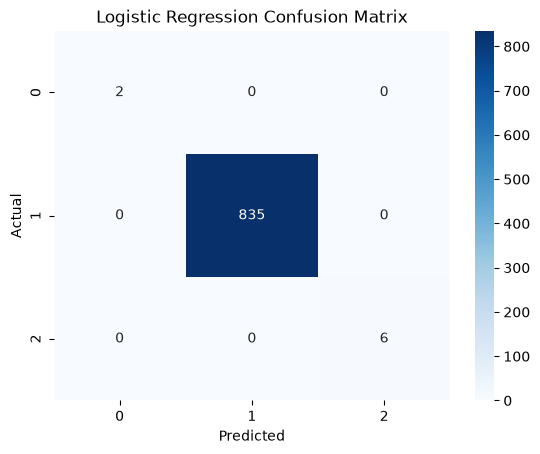

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

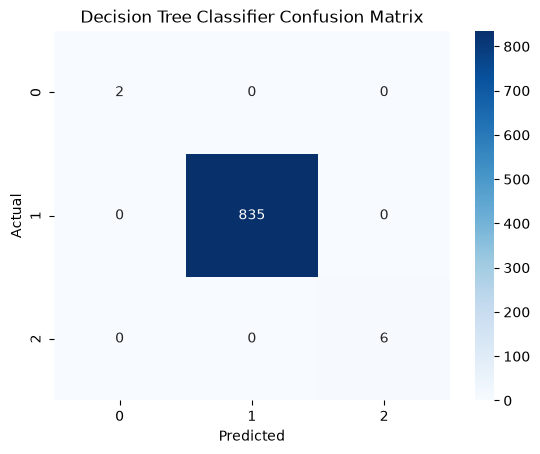

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Classifier Confusion Matrix")

plt.show()

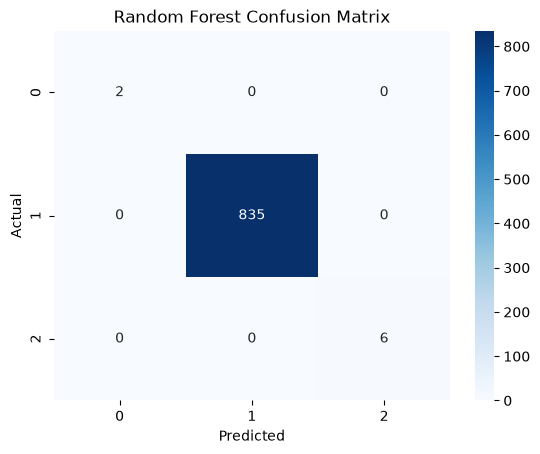

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

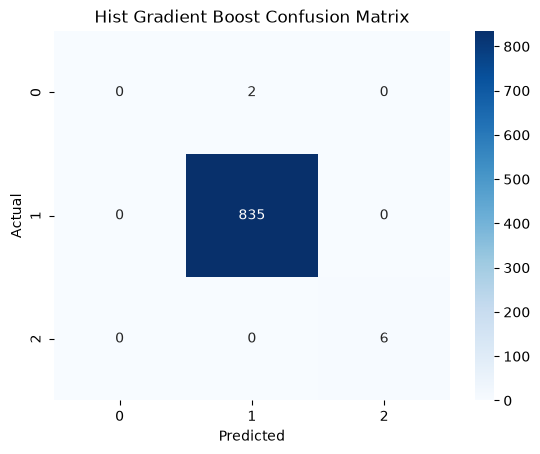

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_hgb)

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hist Gradient Boost Confusion Matrix")

plt.show()

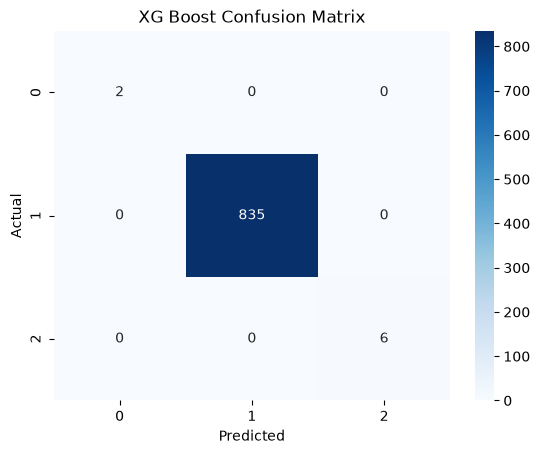

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XG Boost Confusion Matrix")

plt.show()

In [41]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "HistGradientBoost",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_hgb),
        accuracy_score(y_test,y_pred_xgb)
    ]

})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,1.000000
1,Decision Tree,1.000000
2,Random Forest,1.000000
4,XGBoost,1.000000
3,HistGradientBoost,0.997628


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,15,None],
    "min_samples_split":[2,5,10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
import joblib

joblib.dump(rf, "covid_prediction_model.pkl")

In [ ]:
import joblib
from sklearn.preprocessing import LabelEncoder

le_country = LabelEncoder()
df["country"] = le_country.fit_transform(df["country"])

joblib.dump(le_country, "country_encoder.pkl")